In [1]:
import pandas as pd
import heapq
from collections import defaultdict
import matplotlib.pyplot as plt

In [5]:
file_path = "astar_logistics_50_places.csv"
data = pd.read_csv(file_path)

In [6]:
data['Place'] = data['Place'].str.strip().str.upper()
data['Connected_Node'] = data['Connected_Node'].str.strip().str.upper()

In [7]:
graph = defaultdict(list)
heuristic = {}
for _, row in data.iterrows():
    place = row['Place']
    neighbor = row['Connected_Node']
    cost = row['Road_Distance_km']
    h_val = row['Heuristic_to_Agra']

    graph[place].append((neighbor, cost))
    graph[neighbor].append((place, cost))

    heuristic[place] = h_val
    heuristic[neighbor] = h_val

In [8]:
def a_star(start, goal):
    pq = []
    heapq.heappush(pq, (0, start))
    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0
    parent = {start: None}
    while pq:
        current_f, current = heapq.heappop(pq)
        if current == goal:
            break
        for neighbor, cost in graph[current]:
            new_g = g_cost[current] + cost
            if new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g
                f_cost = new_g + heuristic.get(neighbor, 0)

                heapq.heappush(pq, (f_cost, neighbor))
                parent[neighbor] = current
    path = []
    node = goal
    if node not in parent:
        return None, float('inf')
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()
    return path, g_cost[goal]

In [9]:
def evaluate(start_input, goal="AGRA"):
    start = start_input.strip().upper()
    goal = goal.upper()
    if start not in graph:
        print("Invalid start city!")
        return
    path, actual_distance = a_star(start, goal)
    if path is None:
        print("No path found from", start, "to", goal)
        return
    h_start = heuristic.get(start, 0)
    error = abs(actual_distance - h_start)
    accuracy = (1 - (error / actual_distance)) * 100 if actual_distance != 0 else 0
    print("Shortest Path:", " -> ".join(path))
    print("Actual Distance:", actual_distance, "km")
    print("Heuristic:", h_start, "km")
    print("Error:", error, "km")
    print("Accuracy: {:.2f}%".format(accuracy))
    labels = ['Actual Distance', 'Heuristic']
    values = [actual_distance, h_start]
    plt.figure(figsize=(4,4))
    plt.bar(labels, values)
    plt.title("Actual vs Heuristic Distance")
    plt.ylabel("Distance (km)")
    plt.show()
    plt.figure(figsize=(4,4))
    plt.bar(['Accuracy'], [accuracy])
    plt.ylim(0, 100)
    plt.title("Accuracy (%)")
    plt.show()

Enter Start City:  Muzaffarnagar


Shortest Path: MUZAFFARNAGAR -> MEERUT -> GHAZIABAD -> DELHI -> NOIDA -> ALIGARH -> MATHURA -> AGRA
Actual Distance: 395 km
Heuristic: 260 km
Error: 135 km
Accuracy: 65.82%


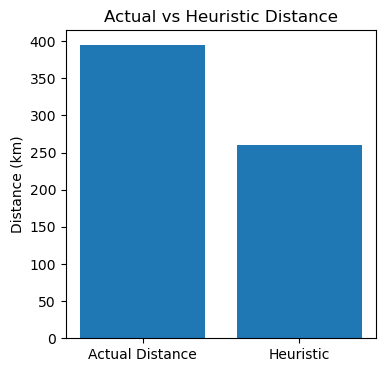

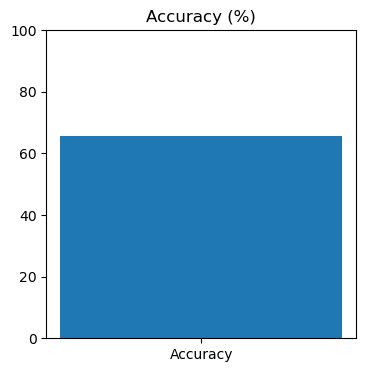

In [11]:
start_node = input("Enter Start City: ")
evaluate(start_node)

Enter Start City:  delhi


Shortest Path: DELHI -> NOIDA -> ALIGARH -> MATHURA -> AGRA
Actual Distance: 260 km
Heuristic: 350 km
Error: 90 km
Accuracy: 65.38%


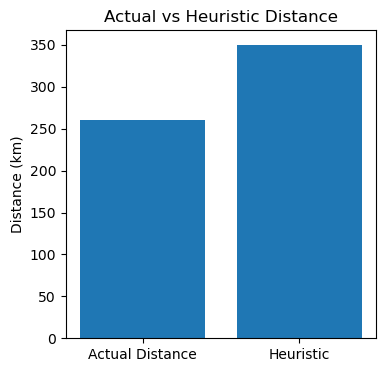

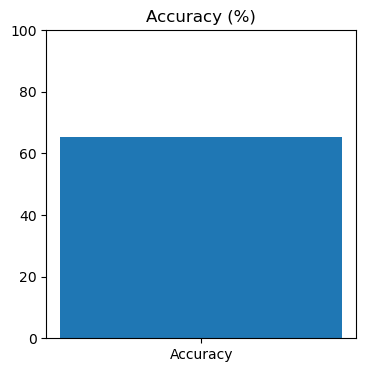

In [13]:
start_node = input("Enter Start City: ")
evaluate(start_node)

Enter Start City:  roorkee


Shortest Path: ROORKEE -> MUZAFFARNAGAR -> MEERUT -> GHAZIABAD -> DELHI -> NOIDA -> ALIGARH -> MATHURA -> AGRA
Actual Distance: 455 km
Heuristic: 290 km
Error: 165 km
Accuracy: 63.74%


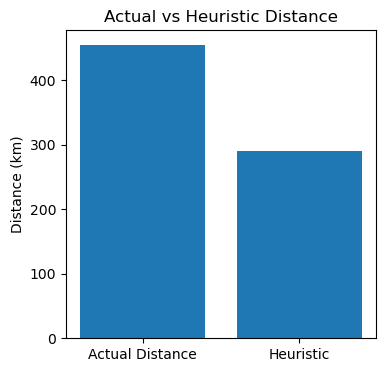

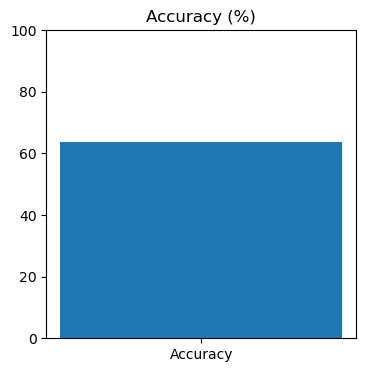

In [14]:
start_node = input("Enter Start City: ")
evaluate(start_node)

Enter Start City:  jaipur


Shortest Path: JAIPUR -> AGRA
Actual Distance: 240 km
Heuristic: 240 km
Error: 0 km
Accuracy: 100.00%


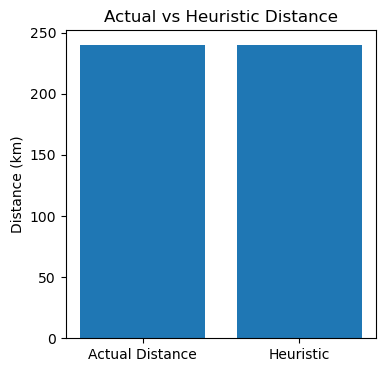

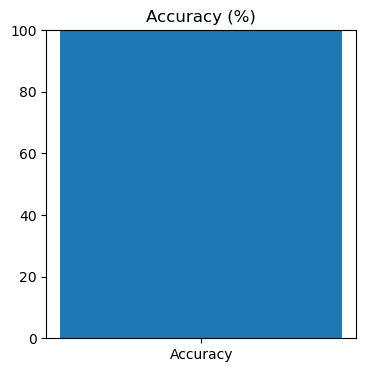

In [15]:
start_node = input("Enter Start City: ")
evaluate(start_node)

Enter Start City:  dehradun


Shortest Path: DEHRADUN -> HARIDWAR -> ROORKEE -> MUZAFFARNAGAR -> MEERUT -> GHAZIABAD -> DELHI -> NOIDA -> ALIGARH -> MATHURA -> AGRA
Actual Distance: 540 km
Heuristic: 330 km
Error: 210 km
Accuracy: 61.11%


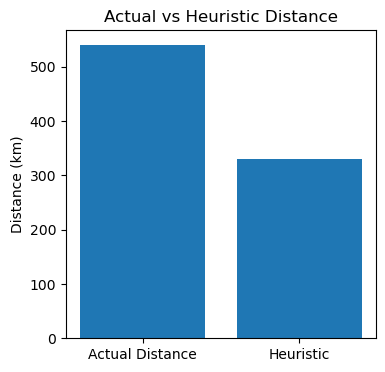

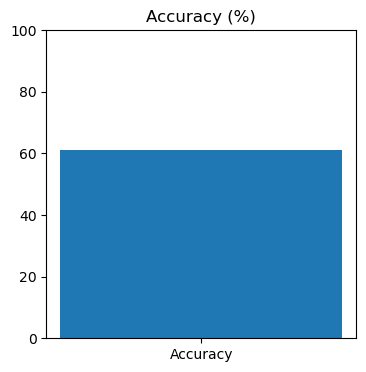

In [17]:
start_node = input("Enter Start City: ")
evaluate(start_node)

In [18]:
start_node = input("Enter Start City: ")
evaluate(start_node)

Enter Start City:  khatima


Invalid start city!
